<a href="https://colab.research.google.com/github/Leo-Mtz/mineria-de-datos/blob/main/mineria_de_datos_P3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#K‑Nearest Neighbors (K-NN) k vecinos más cercanos

##Ejercicio 1: k‑NN manual (k = 1, distancia euclidiana)


###Datos


In [ ]:
import math

# Datos de entrenamiento
X = [(2,4), (4,4), (4,2), (6,2)]
y = ['Rojo', 'Rojo', 'Azul', 'Azul']

# Punto a clasificar
P = (3, 3)

###Función de distancia euclidiana

In [ ]:
def distancia_euclidiana(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

###Cálculo del vecino más cercano

In [ ]:
distancias = []
for i in range(len(X)):
    d = distancia_euclidiana(P, X[i])
    distancias.append((d, y[i]))

# Ordenar por distancia
distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul'), (3.1622776601683795, 'Azul')]
Clase asignada: Rojo


##Ejercicio 2: k‑NN manual con k = 3

In [ ]:
from collections import Counter

k = 3
vecinos = distancias[:k]

clases = [clase for _, clase in vecinos]
resultado = Counter(clases).most_common(1)

print("Vecinos:", vecinos)
print("Clase asignada:", resultado[0][0])

Vecinos: [(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul')]
Clase asignada: Rojo


##Ejercicio 3: Distancia Manhattan

In [ ]:
def distancia_manhattan(p1, p2):
    return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])

X = [(1,1), (2,3), (5,4), (6,5)]
y = ['Baja', 'Baja', 'Alta', 'Alta']
P = (4,3)

distancias = []

for i in range(len(X)):
    d = distancia_manhattan(P, X[i])
    distancias.append((d, y[i]))

distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(2, 'Baja'), (2, 'Alta'), (4, 'Alta'), (5, 'Baja')]
Clase asignada: Baja


##Ejercicio 4: k‑NN con scikit-learn

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

###Datos tipo Iris (reducido)

In [ ]:
X = np.array([
[5.1, 3.5],
[4.9, 3.0],
[6.2, 3.4],
[6.0, 2.9]
])

y = np.array(['Setosa', 'Setosa', 'Versicolor', 'Versicolor'])

P = np.array([[5.8, 3.2]])

###Entrenamiento y predicción

In [ ]:
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

prediccion = modelo.predict(P)
print("Clase predicha:", prediccion[0])

Clase predicha: Versicolor


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Dataset
X = np.array([
[25, 8000],
[30, 12000],
[45, 45000],
[50, 60000],
[35, 15000],
[48, 55000]
])

y = np.array(['Alto', 'Alto', 'Bajo', 'Bajo', 'Alto', 'Bajo'])

nuevo_cliente = np.array([[40, 20000]])

# Modelo k-NN
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

# Predicción
modelo.predict(nuevo_cliente)


array(['Alto'], dtype='<U4')

In [ ]:
from sklearn.preprocessing import StandardScaler

# Escalamiento
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)
nuevo_norm = scaler.transform(nuevo_cliente)

# Modelo k-NN
modelo_norm = KNeighborsClassifier(n_neighbors=3)
modelo_norm.fit(X_norm, y)

# Predicción
modelo_norm.predict(nuevo_norm)

array(['Alto'], dtype='<U4')

In [ ]:
X = [(2,2), (2,4), (4,2), (4,4)]
y = ['A', 'B', 'B', 'A']
P = (3,3)

distancias = [(distancia_euclidiana(P, X[i]), y[i]) for i in range(len(X))]
distancias.sort(key=lambda x: x[0])

k = 4
clases = [clase for _, clase in distancias[:k]]

print("Clases vecinas:", clases)

Clases vecinas: ['A', 'B', 'B', 'A']


In [ ]:
y_correct = np.array(['Alto', 'Alto', 'Bajo', 'Bajo', 'Alto', 'Bajo'])


for k in [1, 3, 5]:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_norm, y_correct)
    print(f"k={k} →", modelo.predict(nuevo_norm)[0])

k=1 → Alto
k=3 → Alto
k=5 → Alto


##Ejercicio de K-NN

### 1. Carga de datos y preparación
Usaremos el dataset Iris disponible en `sklearn`.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Cargar datos
iris = load_iris()
X, y = iris.data, iris.target

# Dividir 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Escalar los datos (recomendado para K-NN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Tamaño entrenamiento: {len(X_train)}")
print(f"Tamaño prueba: {len(X_test)}")

Tamaño entrenamiento: 120
Tamaño prueba: 30


### 2. ¿Qué es el "Codo" (Elbow Method)?
El **método del codo** se utiliza para encontrar el valor óptimo de $k$. Consiste en entrenar el modelo con diferentes valores de $k$ y graficar el error.

Se busca el punto donde la tasa de error disminuye drásticamente y luego comienza a estabilizarse o a disminuir más lentamente; ese punto de inflexión se asemeja a un **codo** y suele ser el mejor balance entre sesgo y varianza.

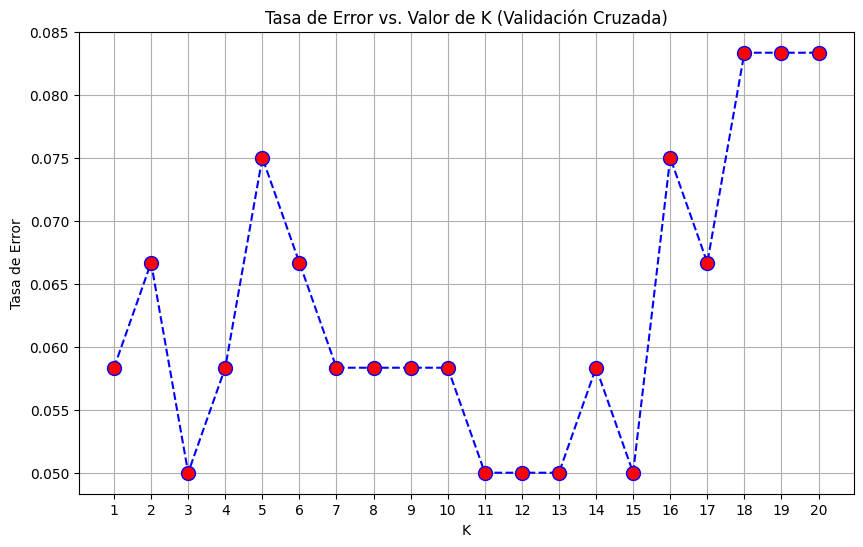

In [ ]:
from sklearn.model_selection import cross_val_score

error_rate = []
k_range = range(1, 21)

# Encontrar el k óptimo usando validación cruzada sobre el conjunto de ENTRENAMIENTO
for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    error_rate.append(1 - scores.mean())

# Graficar el método del codo
plt.figure(figsize=(10,6))
plt.plot(k_range, error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Tasa de Error vs. Valor de K (Validación Cruzada)')
plt.xlabel('K')
plt.ylabel('Tasa de Error')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### 3. Evaluación final con el K óptimo
Basado en el gráfico anterior (donde el error suele ser mínimo o se estabiliza), seleccionamos un valor adecuado (por ejemplo, $k=3$ o $k=5$).

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Determinar el k óptimo: el valor con menor tasa de error del método del codo
k_optimo = range(1, 21)[np.argmin(error_rate)]
print(f"K óptimo encontrado: {k_optimo}")

# Entrenar el modelo final con el k óptimo
modelo_final = KNeighborsClassifier(n_neighbors=k_optimo)
modelo_final.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
predicciones = modelo_final.predict(X_test)

# Mostrar resultados de la evaluación
print(f"--- Resultados con K={k_optimo} ---")
print(f"Precisión total: {accuracy_score(y_test, predicciones):.2f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, predicciones, target_names=iris.target_names))

K óptimo encontrado: 3
--- Resultados con K=3 ---
Precisión total: 1.00

Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



###Prediccion de Liga MX con random forest

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: 9 partidos

 jornada      equipo_local equipo_visita      ganador
      15          Mazatlán     Querétaro       Empate
      15 Atlético San Luis         Pumas   Gana Pumas
      15            Necaxa        Tigres       Empate
      15         Cruz Azul       Tijuana       Empate
      15         Monterrey       Pachuca Gana Pachuca
      15            Chivas        Puebla  Gana Chivas
      15              León     FC Juárez    Gana León
      15           América        Toluca Gana América
      15            Santos         Atlas   Gana Atlas

Distribución: 0=Gana visita, 1=Empate, 2=Gana local
{1: np.int64(3), 0: np.int64(3), 2: np.int64(3)}

Accuracy (train): 100%
                precision    recall  f1-score   support

Gana visitante       1.00      1.00      1.00         3
        Empate       1.00      1.00      1.00         3
    Gana local 

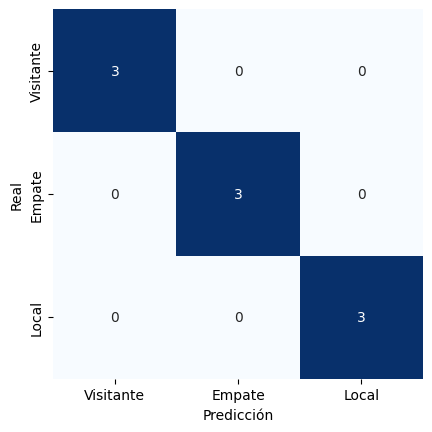

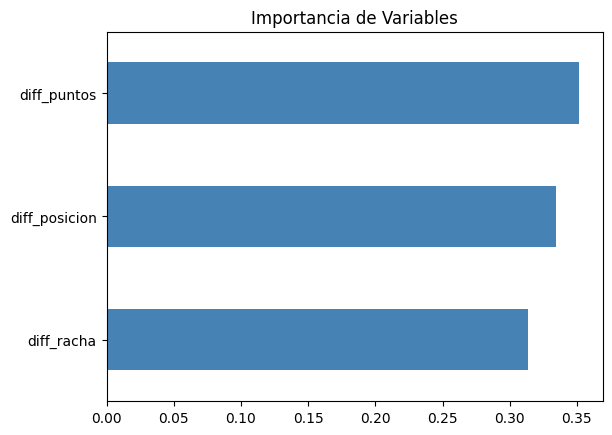


======= PREDICCIONES JORNADA 16 =======

  Querétaro vs Cruz Azul  →  Gana visitante (C)
    Gana visitante (C)     46.8% █████████
    Empate (B)             29.2% █████
    Gana local (A)         24.0% ████

  Pumas vs FC Juárez  →  Gana local (A)
    Gana local (A)         43.8% ████████
    Empate (B)             29.0% █████
    Gana visitante (C)     27.2% █████

  Monterrey vs Puebla  →  Empate (B)
    Empate (B)             69.6% █████████████
    Gana local (A)         30.4% ██████
    Gana visitante (C)      0.0% 

  León vs América  →  Empate (B)
    Empate (B)             50.4% ██████████
    Gana local (A)         49.6% █████████
    Gana visitante (C)      0.0% 

  Atlas vs Tigres  →  Empate (B)
    Empate (B)             79.6% ███████████████
    Gana local (A)         20.4% ████
    Gana visitante (C)      0.0% 

  Atlético San Luis vs Santos  →  Gana local (A)
    Gana local (A)         62.0% ████████████
    Empate (B)             38.0% ███████
    Gana visitante (C) 

In [3]:
# Predicción de Resultados Liga MX con Random Forest
# Basado en el enfoque de Python Data Science Handbook (05.08)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Montar Google Drive y cargar datos
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/dataset_liga_mx_jornadas_13_14_15_base.csv')
print(f"Dataset: {df.shape[0]} partidos\n")

# Mostrar partidos con ganador claro
def ganador(row):
    if row['resultado'] == 2: return f"Gana {row['equipo_local']}"
    elif row['resultado'] == 0: return f"Gana {row['equipo_visita']}"
    else: return "Empate"

resumen = df[['jornada', 'equipo_local', 'equipo_visita']].copy()
resumen['ganador'] = df.apply(ganador, axis=1)
print(resumen.to_string(index=False))
print(f"\nDistribución: 0=Gana visita, 1=Empate, 2=Gana local")
print(dict(df['resultado'].value_counts()))

# 2. Preparar features y entrenar
features = ['diff_puntos', 'diff_racha', 'diff_posicion']
X = df[features].values
y = df['resultado'].values

# Entrenar con todos los datos (pocos partidos, no dividimos)
model = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42)
model.fit(X, y)

# 3. Verificar ajuste
ypred = model.predict(X)
print(f"\nAccuracy (train): {model.score(X, y):.0%}")
print(classification_report(y, ypred, target_names=['Gana visitante', 'Empate', 'Gana local']))

# 4. Matriz de confusión
mat = confusion_matrix(y, ypred)
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=['Visitante', 'Empate', 'Local'],
            yticklabels=['Visitante', 'Empate', 'Local'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# 5. Importancia de variables
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Importancia de Variables')
plt.show()

# 6. Extraer stats por equipo (últimos datos disponibles)
local_stats = df.sort_values('jornada').drop_duplicates('equipo_local', keep='last')
local_stats = local_stats.set_index('equipo_local')[['local_puntos', 'local_racha', 'local_posicion']]
local_stats.columns = ['puntos', 'racha', 'posicion']

visita_stats = df.sort_values('jornada').drop_duplicates('equipo_visita', keep='last')
visita_stats = visita_stats.set_index('equipo_visita')[['visita_puntos', 'visita_racha', 'visita_posicion']]
visita_stats.columns = ['puntos', 'racha', 'posicion']

team_stats = local_stats.combine_first(visita_stats)

# 7. Predecir Jornada 16
partidos_j16 = [
    ('Querétaro', 'Cruz Azul'),
    ('Pumas', 'FC Juárez'),
    ('Monterrey', 'Puebla'),
    ('León', 'América'),
    ('Atlas', 'Tigres'),
    ('Atlético San Luis', 'Santos'),
    ('Mazatlán', 'Toluca'),
    ('Necaxa', 'Chivas'),
    ('Tijuana', 'Pachuca'),
]

etiquetas = {0: 'Gana visitante (C)', 1: 'Empate (B)', 2: 'Gana local (A)'}

print("\n======= PREDICCIONES JORNADA 16 =======\n")
for local, visita in partidos_j16:
    local_key = [t for t in team_stats.index if local in t]
    visita_key = [t for t in team_stats.index if visita in t]

    if not local_key or not visita_key:
        print(f"  {local} vs {visita}: equipo no encontrado")
        continue

    sl = team_stats.loc[local_key[0]]
    sv = team_stats.loc[visita_key[0]]

    x_new = np.array([[sl['puntos'] - sv['puntos'],
                        sl['racha'] - sv['racha'],
                        sl['posicion'] - sv['posicion']]])

    pred = model.predict(x_new)[0]
    probs = model.predict_proba(x_new)[0]

    # Mostrar resultado y confianza
    print(f"  {local} vs {visita}  →  {etiquetas[pred]}")
    for cls, p in sorted(zip(model.classes_, probs), key=lambda x: -x[1]):
        barra = '█' * int(p * 20)
        print(f"    {etiquetas[cls]:22s} {p:5.1%} {barra}")
    print()

